# ADS 542 — Statistical Learning: Bank Marketing Classification

**Objective:** Predict whether a client will subscribe to a term deposit based on the Bank Marketing Dataset.

**Dataset:** [UCI Bank Marketing](https://archive.ics.uci.edu/ml/datasets/Bank+Marketing) — `bank-additional.csv` (4119 samples, 20 input features)

**Context:** The data comes from direct marketing campaigns (phone calls) of a Portuguese banking institution during the 2008–2013 European financial crisis.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    precision_score, recall_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.feature_selection import mutual_info_classif
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('All libraries imported successfully.')

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully.


## 2. Data Loading & Exploration

In [2]:
df = pd.read_csv('bank-additional.csv', sep=';')
print(f'Dataset shape: {df.shape}')
print(f'Number of samples: {df.shape[0]}, Number of features: {df.shape[1]-1}')
df.head()

Dataset shape: (4119, 21)
Number of samples: 4119, Number of features: 20


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [4]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Target variable distribution:
y
no     3668
yes     451
Name: count, dtype: int64

Class ratio (yes/total): 10.9%


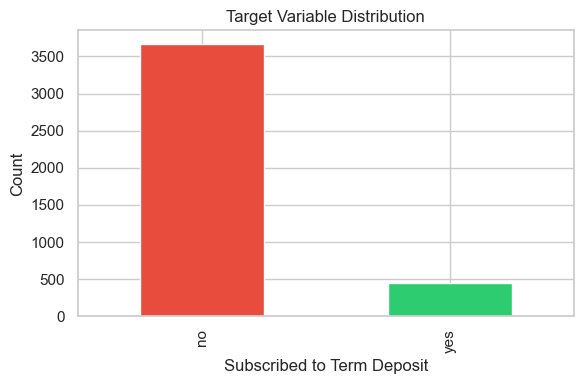

In [5]:
# Target variable distribution
print('Target variable distribution:')
print(df['y'].value_counts())
print(f'\nClass ratio (yes/total): {df["y"].value_counts()["yes"] / len(df) * 100:.1f}%')

fig, ax = plt.subplots(figsize=(6, 4))
df['y'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], ax=ax)
ax.set_title('Target Variable Distribution')
ax.set_xlabel('Subscribed to Term Deposit')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Data Cleaning

### Dropping `duration`
The `duration` column represents the last contact duration in seconds. This attribute is **not known before a call is performed**, so including it would cause **data leakage**. As noted in the dataset documentation: *"this attribute highly affects the output target... should only be included for benchmark purposes."*

In [6]:
# Drop duration — data leakage risk
df = df.drop('duration', axis=1)
print('Dropped duration column (data leakage prevention)')

# Check for missing values encoded as 'unknown'
print('\nunknown value counts per column:')
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f'  {col}: {unknown_count} ({unknown_count/len(df)*100:.1f}%)')

# Check for actual NaN values
print(f'\nActual NaN values: {df.isnull().sum().sum()}')

Dropped duration column (data leakage prevention)

unknown value counts per column:
  job: 39 (0.9%)
  marital: 11 (0.3%)
  education: 167 (4.1%)
  default: 803 (19.5%)
  housing: 105 (2.5%)
  loan: 105 (2.5%)

Actual NaN values: 0


**Note:** 'unknown' values are kept as a separate category rather than imputed, since they may carry predictive information (e.g., a client refusing to disclose information could be a signal).

## 4. Feature Engineering

### Real Interest Rate (Fisher Equation)
In economics, the **Fisher equation** states: *Real Interest Rate ≈ Nominal Interest Rate − Inflation Rate*

Rational individuals make deposit decisions based on **real returns**, not nominal rates. During the 2008–2013 crisis, this distinction was especially important. We create a proxy using Euribor 3M rate and the Consumer Price Index.

In [7]:
# Feature Engineering: Real Interest Rate
df['real_interest_rate'] = df['euribor3m'] - df['cons.price.idx']

print('Created feature: real_interest_rate = euribor3m - cons.price.idx')
print(f'  Mean: {df["real_interest_rate"].mean():.2f}')
print(f'  Std:  {df["real_interest_rate"].std():.2f}')
print(f'  Range: [{df["real_interest_rate"].min():.2f}, {df["real_interest_rate"].max():.2f}]')

Created feature: real_interest_rate = euribor3m - cons.price.idx
  Mean: -89.96
  Std:  1.42
  Range: [-93.74, -88.47]


## 5. Data Preprocessing

In [8]:
# Encode target variable
X = df.drop('y', axis=1)
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numeric features (10): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'real_interest_rate']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [9]:
# Preprocessing pipeline
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print('Preprocessing pipeline created:')
print('  - Numeric: StandardScaler')
print('  - Categorical: OneHotEncoder (handle_unknown=ignore)')

Preprocessing pipeline created:
  - Numeric: StandardScaler
  - Categorical: OneHotEncoder (handle_unknown=ignore)


## 6. Feature Selection

We analyze feature importance using multiple methods:
1. **Correlation analysis** for numeric features
2. **Random Forest feature importance**
3. **Mutual Information scores**

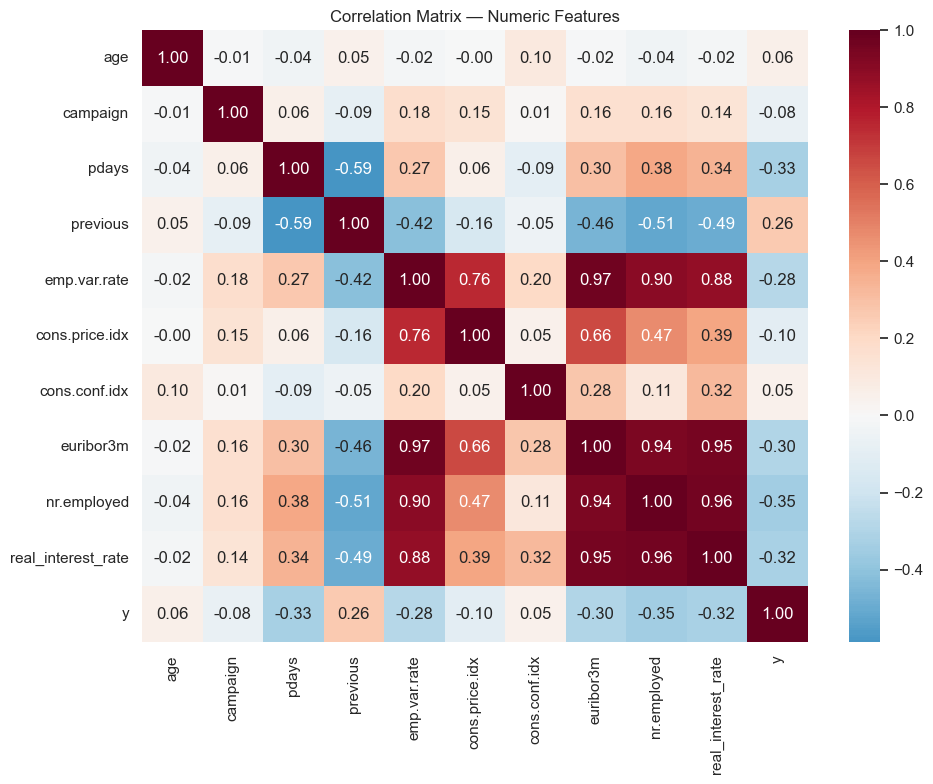


Correlation with target (y):
previous              0.255697
age                   0.060374
cons.conf.idx         0.054393
campaign             -0.076091
cons.price.idx       -0.098326
emp.var.rate         -0.283216
euribor3m            -0.298565
real_interest_rate   -0.324019
pdays                -0.332012
nr.employed          -0.349241


In [10]:
# Correlation matrix for numeric features
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[numeric_features].copy()
corr_matrix['y'] = y
correlation = corr_matrix.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

# Correlation with target
print('\nCorrelation with target (y):')
print(correlation['y'].drop('y').sort_values(ascending=False).to_string())

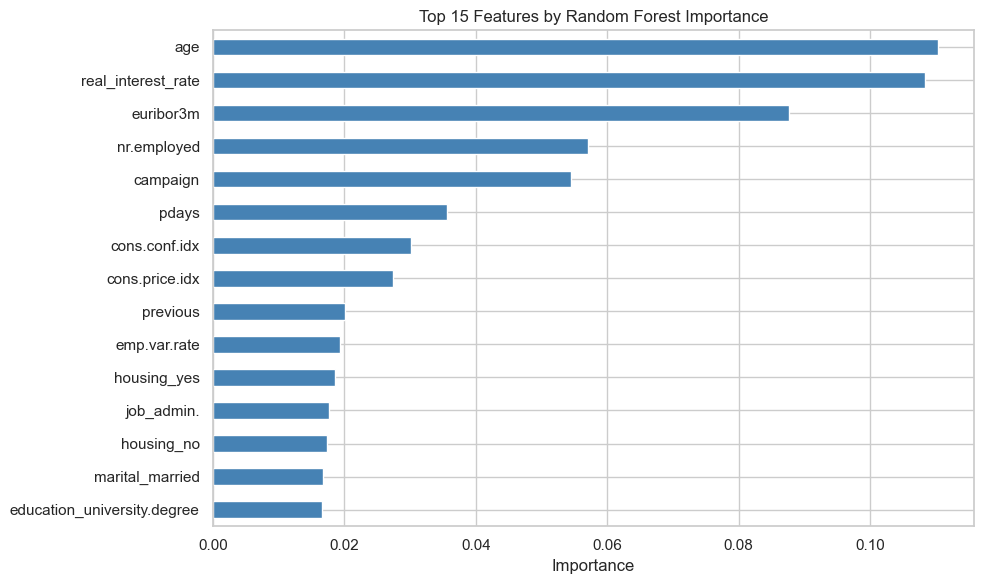

In [11]:
# Feature importance via Random Forest
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Fit a quick RF to get feature importances
temp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
temp_pipeline.fit(X_train_temp, y_train_temp)

# Get feature names after encoding
num_names = numeric_features
cat_names = temp_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_names + cat_names

importances = temp_pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

# Plot top 15 features
fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Features by Random Forest Importance')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
# Mutual Information for numeric features
mi_scores = mutual_info_classif(X[numeric_features], y, random_state=42)
mi_series = pd.Series(mi_scores, index=numeric_features).sort_values(ascending=False)

print('Mutual Information Scores (numeric features):')
print(mi_series.to_string())

Mutual Information Scores (numeric features):
euribor3m             0.068316
real_interest_rate    0.067052
nr.employed           0.059914
cons.price.idx        0.058016
cons.conf.idx         0.057465
emp.var.rate          0.048988
pdays                 0.035761
previous              0.017171
age                   0.015384
campaign              0.001808


**Feature Selection Conclusion:** All features are retained since:
- Economic indicators (`euribor3m`, `nr.employed`, `emp.var.rate`) show strong predictive power
- The engineered `real_interest_rate` feature provides meaningful economic context
- Categorical features like `poutcome` (previous campaign outcome) are highly informative
- The pipeline's regularization and tree-based methods implicitly handle less useful features

## 7. Model Selection & Comparison

We compare three different model families:
1. **Logistic Regression** — Interpretable linear model (econometric approach)
2. **Random Forest** — Ensemble tree-based model
3. **MLP Neural Network** — Deep learning approach

In [13]:
# Train-Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'Training class distribution: {y_train.value_counts().to_dict()}')
print(f'Test class distribution: {y_test.value_counts().to_dict()}')

Training set: 3295 samples
Test set: 824 samples
Training class distribution: {0: 2934, 1: 361}
Test class distribution: {0: 734, 1: 90}


### 7.1 Pipeline with GridSearchCV

A unified `Pipeline` covers preprocessing and classification. `GridSearchCV` with 5-fold cross-validation is used to compare models and tune hyperparameters simultaneously.

In [14]:
# Full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())  # placeholder
])

# Parameter grid: compare 3 model families
param_grid = [
    {
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.01, 0.1, 1, 10]
    },
    {
        'classifier': [RandomForestClassifier(random_state=42)],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10, 20]
    },
    {
        'classifier': [MLPClassifier(max_iter=500, random_state=42)],
        'classifier__hidden_layer_sizes': [(50,), (100,), (50, 50)]
    }
]

# GridSearchCV
grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='f1',
    n_jobs=-1, verbose=1, return_train_score=True)

grid_search.fit(X_train, y_train)

print(f'\nBest Model: {grid_search.best_params_}')
print(f'Best CV F1 Score: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 13 candidates, totalling 65 fits



Best Model: {'classifier': MLPClassifier(max_iter=500, random_state=42), 'classifier__hidden_layer_sizes': (100,)}
Best CV F1 Score: 0.3493


### 7.2 Model Comparison

In [15]:
# Extract results per model family
results = pd.DataFrame(grid_search.cv_results_)

model_results = []
for _, row in results.iterrows():
    clf = row['param_classifier']
    model_name = type(clf).__name__
    model_results.append({
        'Model': model_name,
        'Mean CV F1': round(row['mean_test_score'], 4),
        'Std CV F1': round(row['std_test_score'], 4),
        'Mean Train F1': round(row['mean_train_score'], 4),
        'Rank': int(row['rank_test_score'])
    })

comparison_df = pd.DataFrame(model_results).sort_values('Mean CV F1', ascending=False)
print('Model Comparison (sorted by CV F1 score):')
comparison_df

Model Comparison (sorted by CV F1 score):


,Model,Mean CV F1,Std CV F1,Mean Train F1,Rank
11,MLPClassifier,0.3493,0.0586,0.9909,1
12,MLPClassifier,0.3439,0.0734,0.9948,2
3,LogisticRegression,0.3347,0.0458,0.3824,3
1,LogisticRegression,0.3344,0.0744,0.3579,4
2,LogisticRegression,0.3312,0.0559,0.3703,5
8,RandomForestClassifier,0.3306,0.0534,0.9834,6
0,LogisticRegression,0.3271,0.0582,0.3199,7
5,RandomForestClassifier,0.3261,0.0399,1.0000,8
4,RandomForestClassifier,0.3255,0.0388,1.0000,9
10,MLPClassifier,0.3212,0.0757,0.9334,10


## 8. Evaluation of the Best Model

In [16]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Metrics
print('=' * 50)
print(f'Best Model: {type(best_model.named_steps["classifier"]).__name__}')
print('=' * 50)
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

Best Model: MLPClassifier
Accuracy:  0.8750
Precision: 0.3860
Recall:    0.2444
F1 Score:  0.2993
ROC-AUC:   0.6164

Classification Report:
              precision    recall  f1-score   support

          No       0.91      0.95      0.93       734
         Yes       0.39      0.24      0.30        90

    accuracy                           0.88       824
   macro avg       0.65      0.60      0.62       824
weighted avg       0.85      0.88      0.86       824



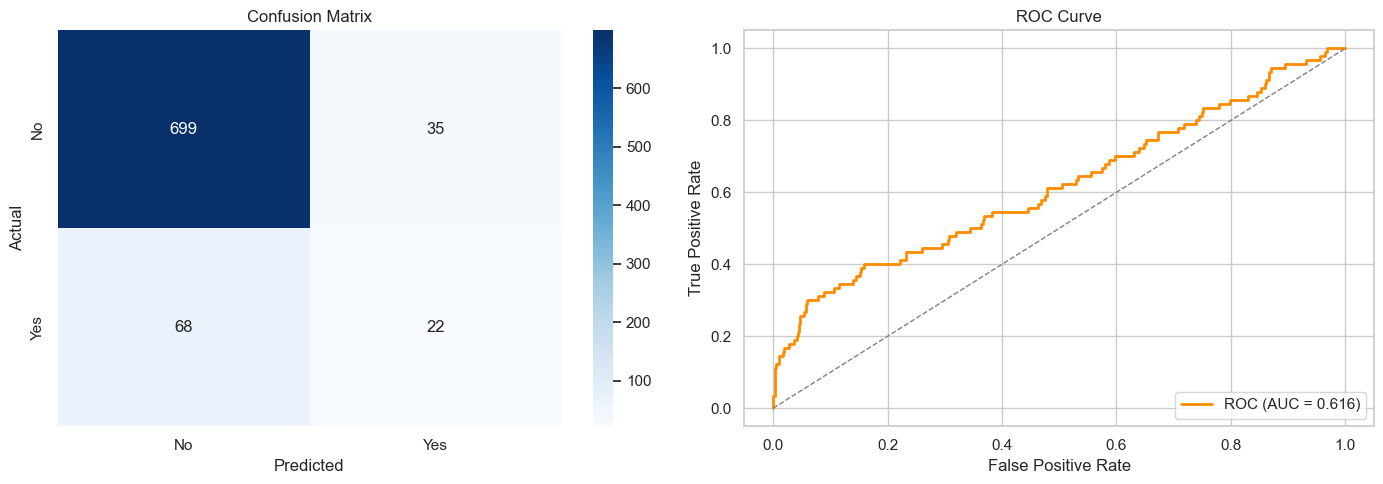

In [17]:
# Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

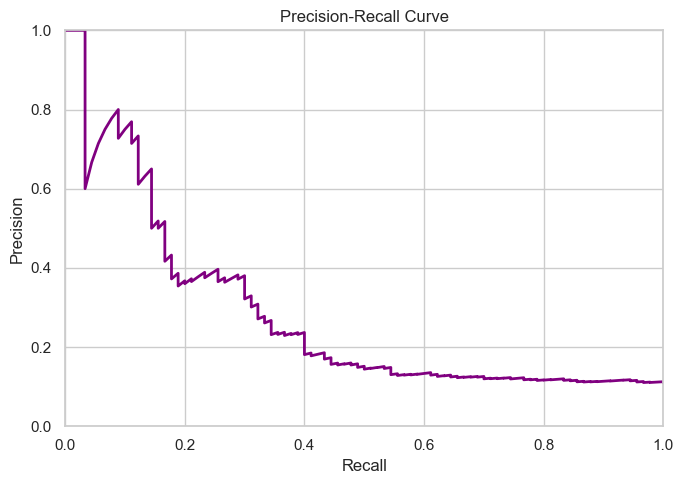

In [18]:
# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_vals, precision_vals, color='purple', lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

## 9. Save Model for Deployment

In [19]:
# Save the best model pipeline
joblib.dump(best_model, 'bank_model.pkl')
print(f'Model saved as bank_model.pkl')
print(f'Pipeline steps: {list(best_model.named_steps.keys())}')
print(f'Model type: {type(best_model.named_steps["classifier"]).__name__}')

Model saved as bank_model.pkl
Pipeline steps: ['preprocessor', 'classifier']
Model type: MLPClassifier


## 10. Deployment

The model is deployed using **Streamlit**. The deployment files are:
- `app.py` — Streamlit web interface
- `bank_model.pkl` — Trained model pipeline
- `requirements.txt` — Python dependencies

### How to Run Locally
```bash
pip install -r requirements.txt
streamlit run app.py
```

### Streamlit Cloud
The application is deployed on Streamlit Cloud. See the report for the URL.